# LSST Classification — Boost: Higher Macro F1

**Goal**: Push Macro F1 higher by combining:
1. **Synthetic oversampling** of rare classes (53: 7→80 samples, 64: 24→80)
2. **InceptionTime-Large ×5** trained up to **500 epochs** (early stop patience=50)
3. Same ensemble as `Chronos.ipynb` — reuses saved checkpoints where possible

| Property | Value |
|----------|-------|
| Dataset | LSST (PLAsTiCC) — 14 classes, (N, T=36, C=6) |
| Setting | 1 — Adapt a pre-trained foundation model |
| Target | Macro F1 > 0.50 while keeping Accuracy > 0.63 |

---
## 1. Colab Setup

In [4]:
import os, sys, subprocess

IN_COLAB = 'google.colab' in sys.modules
print(f'Running in Colab: {IN_COLAB}')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    REPO_URL  = 'https://github.com/coulzie031/DeepLearningForTimeSeries.git'
    REPO_DIR  = '/content/lsst1'
    DRIVE_DIR = '/content/drive/MyDrive/lsst1_boost'

    if not os.path.exists(REPO_DIR):
        subprocess.run(['git', 'clone', '-b', 'chronos', REPO_URL, REPO_DIR])
    else:
        subprocess.run(['git', '-C', REPO_DIR, 'pull'])
    os.chdir(REPO_DIR)
    sys.path.insert(0, REPO_DIR)

    os.makedirs(DRIVE_DIR, exist_ok=True)
    if not os.path.exists(f'{REPO_DIR}/results_boost'):
        os.symlink(DRIVE_DIR, f'{REPO_DIR}/results_boost')

    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'git+https://github.com/amazon-science/chronos-forecasting.git'])
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'huggingface_hub', 'transformers', 'sktime', 'aeon'])
    print('Dependencies installed.')
else:
    ROOT = os.path.abspath('.')
    if ROOT not in sys.path:
        sys.path.insert(0, ROOT)
    DRIVE_DIR = 'results_boost'
    print(f'Local mode — ROOT: {ROOT}')

Running in Colab: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dependencies installed.


In [5]:
import math, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')

from data.lsst_dataset import (
    load_lsst, preprocess, get_dataloaders,
    compute_class_weights, LSSTPatchDataset
)
from models.inception_time import InceptionTime
from models.moment_classifier import PatchTSTClassifier
from models.chronos_classifier import ChronosClassifier
from archive.utils import (
    seed_everything, EarlyStopping, eval_epoch,
    compute_metrics, get_embeddings, save_logs, FocalLoss
)

seed_everything(42)
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP    = (DEVICE.type == 'cuda')
RD         = 'results_boost'
RD_MAIN    = 'results'
os.makedirs(RD, exist_ok=True)
NUM_CLASSES = 14
N_CHANNELS  = 6

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'AMP    : {USE_AMP}')


Device : cuda
GPU    : Tesla T4
AMP    : True


---
## 2. Load Data

In [6]:
X_train_raw, y_train, X_test_raw, y_test, le = load_lsst()
CLASS_NAMES = [str(c) for c in le.classes_]
counts_train = Counter(y_train)
print('Train class counts:')
for i, n in sorted(counts_train.items(), key=lambda x: x[1]):
    flag = ' ← RARE' if n < 30 else ''
    print(f'  Class {CLASS_NAMES[i]:>4}: {n:4d} samples{flag}')

  LSST loaded — train: (2459, 36, 6), test: (2466, 36, 6)
  Shape: (N, T=36, C=6)
  Classes: ['15', '16', '42', '52', '53', '6', '62', '64', '65', '67', '88', '90', '92', '95']
  NaN rate (train): 0.0%
Train class counts:
  Class   53:    7 samples ← RARE
  Class   64:   23 samples ← RARE
  Class    6:   34 samples
  Class   95:   51 samples
  Class   52:   62 samples
  Class   67:   68 samples
  Class   92:   77 samples
  Class   88:  120 samples
  Class   15:  123 samples
  Class   62:  153 samples
  Class   16:  270 samples
  Class   65:  313 samples
  Class   42:  381 samples
  Class   90:  777 samples


---
## 3. Synthetic Minority Oversampling

For classes with fewer than `TARGET` training samples, we generate synthetic samples
by **interpolating between two real samples of the same class** and adding small Gaussian noise.
This is a simple time-series adaptation of SMOTE.

**Why this helps Macro F1:**
- Classes 53 (7 samples) and 64 (24 samples) have F1=0 because the model never sees enough examples
- Upsampling to 80 synthetic samples gives the model a real chance to learn their patterns

In [7]:
def synthetic_oversample(X, y, target=80, random_state=42):
    """Upsample rare classes by interpolation between pairs of same-class samples."""
    rng = np.random.RandomState(random_state)
    X_out, y_out = list(X), list(y)

    counts = Counter(y)
    for cls, n in counts.items():
        if n >= target:
            continue
        idxs = np.where(y == cls)[0]
        n_needed = target - n
        print(f'  Class {cls} ({CLASS_NAMES[cls]}): {n} → {target} (+{n_needed} synthetic)')
        for _ in range(n_needed):
            if len(idxs) >= 2:
                i, j = rng.choice(idxs, 2, replace=False)
                lam = rng.uniform(0.2, 0.8)
                x_new = lam * X[i] + (1 - lam) * X[j]
            else:
                # Only 1 sample — augment it
                x_new = X[idxs[0]].copy()
            # Add small noise
            x_new = x_new + rng.randn(*x_new.shape) * 0.03
            X_out.append(x_new)
            y_out.append(cls)

    return np.array(X_out, dtype=np.float32), np.array(y_out)


# Oversample classes with < 80 train samples
TARGET_PER_CLASS = 80
print('Oversampling rare classes...')
X_train_aug, y_train_aug = synthetic_oversample(X_train_raw, y_train, target=TARGET_PER_CLASS)
print(f'\nTrain set: {len(y_train)} → {len(y_train_aug)} samples')

aug_counts = Counter(y_train_aug)
print(f'Imbalance ratio after oversampling: {max(aug_counts.values())/min(aug_counts.values()):.1f}:1')

Oversampling rare classes...
  Class 5 (6): 34 → 80 (+46 synthetic)
  Class 3 (52): 62 → 80 (+18 synthetic)
  Class 4 (53): 7 → 80 (+73 synthetic)
  Class 7 (64): 23 → 80 (+57 synthetic)
  Class 9 (67): 68 → 80 (+12 synthetic)
  Class 12 (92): 77 → 80 (+3 synthetic)
  Class 13 (95): 51 → 80 (+29 synthetic)

Train set: 2459 → 2697 samples
Imbalance ratio after oversampling: 9.7:1


---
## 4. DataLoaders

In [8]:
AUG_KW = dict(jitter_sigma=0.04, scale_range=(0.85, 1.15),
              channel_drop_p=0.15, time_warp_p=0.25)

# DataLoaders on AUGMENTED train set
(train_loader, val_loader, test_loader,
 X_test_norm, test_mask) = get_dataloaders(
    X_train_aug, y_train_aug, X_test_raw, y_test,
    val_ratio=0.2, batch_size=64, aug_kwargs=AUG_KW,
    random_state=42, use_weighted_sampler=True,
)

(train_ldr32, val_ldr32, _, _, _) = get_dataloaders(
    X_train_aug, y_train_aug, X_test_raw, y_test,
    val_ratio=0.2, batch_size=32, aug_kwargs=AUG_KW,
    random_state=42, use_weighted_sampler=True,
)

# Also keep original split for Chronos checkpoint compatibility
X_train_norm, train_mask = preprocess(X_train_raw)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(sss.split(X_train_norm, y_train))
y_va = y_train[va_idx]

class_w    = compute_class_weights(y_train_aug, NUM_CLASSES).to(DEVICE)
focal_crit = FocalLoss(gamma=2.0)
print('DataLoaders ready.')

  Split — train: 2157  val: 540  test: 2466
  WeightedRandomSampler ON (K=14)
  Split — train: 2157  val: 540  test: 2466
  WeightedRandomSampler ON (K=14)
DataLoaders ready.


---
## 5. Training Helpers

In [9]:
def lr_cos(epoch, lr=3e-4, min_lr=1e-7, warmup=10, total=1000):
    if epoch <= warmup: return lr * epoch / max(1, warmup)
    t = (epoch - warmup) / max(1, total - warmup)
    return min_lr + (lr - min_lr) * 0.5 * (1 + math.cos(math.pi * t))


def fit(model, tl, vl, crit, epochs, lr, patience, ckpt,
        mixup=False, use_amp=USE_AMP, verbose_every=50):
    opt    = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                                lr=lr, weight_decay=1e-3)
    es     = EarlyStopping(patience=patience, mode='max')
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and DEVICE.type == 'cuda'))
    best_f1, best_state = 0.0, None

    for ep in range(1, epochs + 1):
        lr_now = lr_cos(ep, lr=lr, total=epochs)
        for pg in opt.param_groups: pg['lr'] = lr_now

        model.train()
        tl_, tc_, tn_ = 0., 0, 0
        for xb, mb, yb in tl:
            xb, mb, yb = xb.to(DEVICE), mb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(use_amp and DEVICE.type == 'cuda')):
                if mixup:
                    lam  = float(np.random.beta(0.3, 0.3))
                    perm = torch.randperm(xb.size(0), device=DEVICE)
                    logits = model(lam*xb + (1-lam)*xb[perm],
                                   torch.minimum(mb, mb[perm]))
                    loss = lam*crit(logits, yb) + (1-lam)*crit(logits, yb[perm])
                else:
                    logits = model(xb, mb)
                    loss   = crit(logits, yb)
            if not math.isfinite(loss.item()):
                opt.zero_grad(set_to_none=True); tn_ += len(yb); continue
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            tl_ += loss.item()*len(yb)
            tc_ += (logits.detach().argmax(1) == yb).sum().item()
            tn_ += len(yb)

        tl_ /= max(1, tn_); ta_ = tc_ / max(1, tn_)
        vl_, va_, vp, vt = eval_epoch(model, vl, crit, DEVICE)
        vf_ = f1_score(vt, vp, average='macro', zero_division=0)

        if vf_ > best_f1:
            best_f1 = vf_
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            if ckpt: torch.save(best_state, ckpt)
        if ep % verbose_every == 0:
            print(f'  Ep{ep:4d}  TrLoss={tl_:.4f} TrAcc={ta_:.3f}  '
                  f'VlAcc={va_:.3f} VlF1={vf_:.3f}  lr={lr_now:.2e}')
        if es(vf_):
            print(f'  → Early stop ep{ep} (best F1={best_f1:.4f})')
            break

    if best_state: model.load_state_dict(best_state)
    print(f'  Best val Macro F1: {best_f1:.4f}')
    return best_f1


@torch.no_grad()
def get_probas_tta(model, X_norm, mask, y, n_tta=5, batch_size=64):
    model.eval()
    p_sum, all_y = None, []
    for aug in range(n_tta):
        ds = LSSTPatchDataset(X_norm, y, mask, augment=(aug > 0),
                               jitter_sigma=0.02, scale_range=(0.95, 1.05),
                               channel_drop_p=0.05, time_warp_p=0.1)
        ldr = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        batch_p = []
        for xb, mb, yb in ldr:
            batch_p.append(
                F.softmax(model(xb.to(DEVICE), mb.to(DEVICE)), dim=1).cpu().numpy()
            )
            if aug == 0: all_y.append(yb.numpy())
        p = np.concatenate(batch_p)
        p_sum = p if p_sum is None else p_sum + p
    return p_sum / n_tta, np.concatenate(all_y)


@torch.no_grad()
def get_val_f1(model, val_loader):
    model.eval()
    preds, targets = [], []
    for xb, mb, yb in val_loader:
        preds.append(model(xb.to(DEVICE), mb.to(DEVICE)).argmax(1).cpu().numpy())
        targets.append(yb.numpy())
    return f1_score(np.concatenate(targets), np.concatenate(preds),
                    average='macro', zero_division=0)


print('Training helpers defined.')

Training helpers defined.


---
## 6. InceptionTime-Large × 5 — 1000 epochs with oversampled data

Key difference vs `Chronos.ipynb`:
- Trained on **augmented + oversampled** dataset (rare classes have 80 samples)
- **1000 max epochs** with patience=100 — lets the model really learn rare classes
- LR=3e-4 (optimal for AdamW on this dataset size), cosine schedule with 10-epoch warmup
- Separate checkpoints saved in `results_boost/`

In [10]:
print('=' * 60)
print('  InceptionTime-Large × 5  (1000 epochs, lr=3e-4, oversampled)')
print('=' * 60)

IT5_SEEDS  = [42, 123, 456, 789, 2024]
it5_probas = []
it5_val_f1 = []

for seed in IT5_SEEDS:
    ckpt_s = f'{RD}/best_boost_it5_s{seed}.pt'
    seed_everything(seed)

    tl_s, vl_s, _, _, _ = get_dataloaders(
        X_train_aug, y_train_aug, X_test_raw, y_test,
        val_ratio=0.2, batch_size=64, aug_kwargs=AUG_KW,
        random_state=seed, use_weighted_sampler=True,
    )

    m = InceptionTime(
        n_channels=N_CHANNELS, num_classes=NUM_CLASSES,
        nb_filters=64, kernel_sizes=(9, 19, 39),
        n_blocks=3, dropout=0.2,
    ).to(DEVICE)

    if os.path.exists(ckpt_s):
        print(f'  [s={seed}] checkpoint found')
        m.load_state_dict(torch.load(ckpt_s, map_location=DEVICE, weights_only=True))
    else:
        print(f'  [s={seed}] training up to 1000 epochs...')
        fit(m, tl_s, vl_s, focal_crit,
            epochs=1000, lr=3e-4, patience=100, ckpt=ckpt_s, mixup=False)

    vf = get_val_f1(m, val_loader)
    p_te, y_te = get_probas_tta(m, X_test_norm, test_mask, y_test, n_tta=5)
    te_f1 = f1_score(y_te, p_te.argmax(1), average='macro', zero_division=0)
    print(f'  [s={seed}] Val F1={vf:.4f}  Test Acc={(p_te.argmax(1)==y_te).mean():.4f}  Test F1={te_f1:.4f}')

    it5_probas.append(p_te)
    it5_val_f1.append(vf)

seed_everything(42)

p_it5_avg  = np.mean(it5_probas, axis=0)
vf_it5_avg = np.mean(it5_val_f1)
f1_it5 = f1_score(y_te, p_it5_avg.argmax(1), average='macro', zero_division=0)
acc_it5 = (p_it5_avg.argmax(1) == y_te).mean()
print(f'\nIT×5 (boost) — Test Acc={acc_it5:.4f}  Macro F1={f1_it5:.4f}')

  InceptionTime-Large × 5  (1000 epochs, lr=3e-4, oversampled)
  Split — train: 2157  val: 540  test: 2466
  WeightedRandomSampler ON (K=14)
  [s=42] training up to 1000 epochs...
  Ep  50  TrLoss=0.1221 TrAcc=0.930  VlAcc=0.561 VlF1=0.570  lr=2.99e-04
  Ep 100  TrLoss=0.0634 TrAcc=0.955  VlAcc=0.554 VlF1=0.589  lr=2.94e-04
  Ep 150  TrLoss=0.0433 TrAcc=0.972  VlAcc=0.661 VlF1=0.624  lr=2.85e-04
  Ep 200  TrLoss=0.0364 TrAcc=0.974  VlAcc=0.617 VlF1=0.616  lr=2.74e-04
  Ep 250  TrLoss=0.0313 TrAcc=0.977  VlAcc=0.594 VlF1=0.597  lr=2.59e-04
  Ep 300  TrLoss=0.0260 TrAcc=0.980  VlAcc=0.631 VlF1=0.612  lr=2.41e-04
  Ep 350  TrLoss=0.0245 TrAcc=0.983  VlAcc=0.620 VlF1=0.611  lr=2.21e-04
  Ep 400  TrLoss=0.0116 TrAcc=0.992  VlAcc=0.667 VlF1=0.636  lr=1.99e-04
  → Early stop ep445 (best F1=0.6415)
  Best val Macro F1: 0.6415
  [s=42] Val F1=0.6415  Test Acc=0.5872  Test F1=0.4243
  Split — train: 2157  val: 540  test: 2466
  WeightedRandomSampler ON (K=14)
  [s=123] training up to 1000 epochs

---
## 7. PatchTST — 1000 epochs with oversampled data

In [11]:
print('=' * 60)
print('  PatchTST  (d=64, 4 heads, 3 layers — 1000 epochs, lr=3e-4)')
print('=' * 60)

CKPT_PTST = f'{RD}/best_boost_patchtst.pt'
patchtst = PatchTSTClassifier(
    seq_len=36, n_channels=N_CHANNELS, num_classes=NUM_CLASSES,
    patch_len=6, stride=3, d_model=64, n_heads=4, n_layers=3,
    dropout=0.15, dropout_head=0.3,
).to(DEVICE)
print(f'  Params: {sum(p.numel() for p in patchtst.parameters()):,}')

if os.path.exists(CKPT_PTST):
    patchtst.load_state_dict(torch.load(CKPT_PTST, map_location=DEVICE, weights_only=True))
    print('  Checkpoint found')
else:
    fit(patchtst, train_loader, val_loader, focal_crit,
        epochs=1000, lr=3e-4, patience=100, ckpt=CKPT_PTST, mixup=True)

vf_ptst = get_val_f1(patchtst, val_loader)
p_ptst, y_ptst = get_probas_tta(patchtst, X_test_norm, test_mask, y_test, n_tta=5)
f1_ptst = f1_score(y_ptst, p_ptst.argmax(1), average='macro', zero_division=0)
acc_ptst = (p_ptst.argmax(1) == y_ptst).mean()
print(f'  PatchTST: Val F1={vf_ptst:.4f}  Test Acc={acc_ptst:.4f}  Test F1={f1_ptst:.4f}')

  PatchTST  (d=64, 4 heads, 3 layers — 1000 epochs, lr=3e-4)
  Params: 253,402
  Ep  50  TrLoss=1.0763 TrAcc=0.351  VlAcc=0.465 VlF1=0.506  lr=2.99e-04
  Ep 100  TrLoss=1.0007 TrAcc=0.424  VlAcc=0.520 VlF1=0.536  lr=2.94e-04
  Ep 150  TrLoss=0.7639 TrAcc=0.446  VlAcc=0.543 VlF1=0.550  lr=2.85e-04
  Ep 200  TrLoss=0.7600 TrAcc=0.444  VlAcc=0.563 VlF1=0.592  lr=2.74e-04
  Ep 250  TrLoss=0.6766 TrAcc=0.401  VlAcc=0.591 VlF1=0.612  lr=2.59e-04
  Ep 300  TrLoss=0.8037 TrAcc=0.455  VlAcc=0.583 VlF1=0.582  lr=2.41e-04
  Ep 350  TrLoss=0.6941 TrAcc=0.459  VlAcc=0.607 VlF1=0.606  lr=2.21e-04
  Ep 400  TrLoss=0.5732 TrAcc=0.555  VlAcc=0.607 VlF1=0.610  lr=1.99e-04
  → Early stop ep447 (best F1=0.6331)
  Best val Macro F1: 0.6331
  PatchTST: Val F1=0.6331  Test Acc=0.5848  Test F1=0.4403


---
## 8. Chronos


In [14]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'git+https://github.com/amazon-science/chronos-forecasting.git'])

import models.chronos_classifier as _chr_mod
from models.chronos_classifier import ChronosClassifier

def _encode_patched(self, x, mask=None):
    import torch
    B, T, C = x.shape
    channel_embs = []
    for c in range(C):
        xc = x[:, :, c].cpu().float()
        input_ids, attention_mask, _ = self.pipeline.tokenizer._input_transform(xc)
        input_ids      = input_ids.to(self._device)
        attention_mask = attention_mask.to(self._device)
        enc_out = self.pipeline.model.model.encoder(
            input_ids=input_ids, attention_mask=attention_mask,
        )
        hidden = enc_out.last_hidden_state.float()
        attn_f = attention_mask.float().unsqueeze(-1)
        emb_c  = (hidden * attn_f).sum(1) / attn_f.sum(1).clamp(min=1)
        channel_embs.append(emb_c)
    return torch.cat(channel_embs, dim=1)

_chr_mod.ChronosClassifier.encode = _encode_patched

CKPT_CHR = f'{RD}/best_boost_chronos.pt'
chronos_model = None
vf_chr, p_chr_te = 0.0, None

try:
    chronos_model = ChronosClassifier(num_classes=NUM_CLASSES, n_channels=N_CHANNELS).to(DEVICE)
    chronos_model.load_chronos(device=str(DEVICE))

    (train_ldr_chr, val_ldr_chr, _,
     X_te_n, te_mask) = get_dataloaders(
        X_train_raw, y_train, X_test_raw, y_test,
        val_ratio=0.2, batch_size=32, random_state=42,
        use_weighted_sampler=True,
    )

    if os.path.exists(CKPT_CHR):
        chronos_model.load_state_dict(
            torch.load(CKPT_CHR, map_location=DEVICE, weights_only=True))
        print('Chronos checkpoint loaded.')
    else:
        print('Training Chronos from scratch...')
        fit(chronos_model, train_ldr_chr, val_ldr_chr, focal_crit,
            epochs=200, lr=1e-4, patience=20, ckpt=CKPT_CHR, mixup=False)

    vf_chr = get_val_f1(chronos_model, val_ldr_chr)
    p_chr_te, _ = get_probas_tta(chronos_model, X_te_n, te_mask, y_test, n_tta=3)
    acc_chr = (p_chr_te.argmax(1) == y_test).mean()
    f1_chr  = f1_score(y_test, p_chr_te.argmax(1), average='macro', zero_division=0)
    print(f'Chronos — Acc={acc_chr:.4f}  Macro F1={f1_chr:.4f}  Val F1={vf_chr:.4f}')

except Exception as e:
    print(f'Chronos skipped: {e}')
    chronos_model = None


  Loading Chronos backbone from 'amazon/chronos-t5-small' ...
  Chronos d_model=512  emb_dim=3072
  Chronos loaded — backbone params=46,154,240  head_input=3072
  Split — train: 1967  val: 492  test: 2466
  WeightedRandomSampler ON (K=14)
Training Chronos from scratch...
  Ep  50  TrLoss=0.2382 TrAcc=0.844  VlAcc=0.547 VlF1=0.388  lr=8.95e-05
  → Early stop ep68 (best F1=0.4465)
  Best val Macro F1: 0.4465
Chronos — Acc=0.5645  Macro F1=0.4459  Val F1=0.4465


---
## 9. MultiROCKET

In [15]:
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

CKPT_ROCKET = f'{RD}/hydra_rocket_boost.npz'
p_rocket, vf_rocket = None, 0.0

X_train_norm_aug, train_mask_aug = preprocess(X_train_aug)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr2, va2 = next(sss2.split(X_train_norm_aug, y_train_aug))
X_tr_nct = X_train_norm_aug[tr2].transpose(0, 2, 1).astype(np.float32)
X_va_nct = X_train_norm_aug[va2].transpose(0, 2, 1).astype(np.float32)
X_te_nct = X_test_norm.transpose(0, 2, 1).astype(np.float32)
y_tr2, y_va2 = y_train_aug[tr2], y_train_aug[va2]

if os.path.exists(CKPT_ROCKET):
    d = np.load(CKPT_ROCKET)
    p_rocket  = d['p_rocket']
    vf_rocket = float(d['vf_rocket'])
    print(f'MultiROCKET loaded. Val F1={vf_rocket:.4f}')
else:
    try:
        from aeon.transformations.collection.convolution_based import MultiRocket
        rocket = MultiRocket(random_state=42)
        print('Fitting MultiRocket on oversampled data...')
        Ztr = rocket.fit_transform(X_tr_nct)
        Zva = rocket.transform(X_va_nct)
        Zte = rocket.transform(X_te_nct)
        print(f'Feature dim: {Ztr.shape[1]}')

        ridge = make_pipeline(
            StandardScaler(with_mean=False),
            RidgeClassifierCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100])
        )
        ridge.fit(Ztr, y_tr2)
        vf_rocket = f1_score(y_va2, ridge.predict(Zva), average='macro', zero_division=0)

        df = ridge.decision_function(Zte)
        if df.ndim == 1: df = np.column_stack([-df, df])
        df -= df.max(axis=1, keepdims=True)
        p_rocket = np.exp(df); p_rocket /= p_rocket.sum(axis=1, keepdims=True)
        np.savez(CKPT_ROCKET, p_rocket=p_rocket, vf_rocket=vf_rocket)
        print(f'MultiROCKET Val F1={vf_rocket:.4f}')
    except Exception as e:
        print(f'MultiROCKET failed: {e}')

if p_rocket is not None:
    f1_r = f1_score(y_test, p_rocket.argmax(1), average='macro', zero_division=0)
    print(f'MultiROCKET: Test Acc={(p_rocket.argmax(1)==y_test).mean():.4f}  Macro F1={f1_r:.4f}')

Fitting MultiRocket on oversampled data...
Feature dim: 49728
MultiROCKET Val F1=0.6108
MultiROCKET: Test Acc=0.5977  Macro F1=0.3776


---
## 10. Ensemble — Soft Voting (F1-weighted)

In [16]:
def exp_weights(f1_list, T=10.0):
    s = np.array(f1_list, dtype=np.float64) * T
    s -= s.max()
    w = np.exp(s)
    return w / w.sum()


MIN_ENS_F1 = 0.33

all_probas = [p_it5_avg]
all_vf1    = [vf_it5_avg]
all_names  = ['IT-Large×5 (boost)']

if vf_ptst >= MIN_ENS_F1:
    all_probas.append(p_ptst); all_vf1.append(vf_ptst); all_names.append('PatchTST')

if chronos_model is not None and vf_chr >= MIN_ENS_F1:
    all_probas.append(p_chr_te); all_vf1.append(vf_chr); all_names.append('Chronos-T5')

if p_rocket is not None and vf_rocket >= MIN_ENS_F1:
    all_probas.append(p_rocket); all_vf1.append(vf_rocket); all_names.append('MultiROCKET')

print(f'Ensemble members: {all_names}')

weights  = exp_weights(all_vf1)
p_ens    = sum(w * p for w, p in zip(weights, all_probas))
ens_pred = p_ens.argmax(1)

acc_ens = (ens_pred == y_test).mean()
f1_ens  = f1_score(y_test, ens_pred, average='macro', zero_division=0)
f1_ens_w = f1_score(y_test, ens_pred, average='weighted', zero_division=0)
_, _, rep_ens, cm_ens = compute_metrics(y_test, ens_pred, le)

np.save(f'{RD}/boost_ensemble_preds.npy',   ens_pred)
np.save(f'{RD}/boost_ensemble_targets.npy', y_test)

print('\n' + '='*60)
print('  ENSEMBLE WEIGHTS')
print('='*60)
for name, vf1, w in zip(all_names, all_vf1, weights):
    print(f'  {name:<30}  Val F1={vf1:.4f}  Weight={w:.4f}')

print(f'\n  ► Ensemble Accuracy   : {acc_ens:.4f}')
print(f'  ► Ensemble Macro F1   : {f1_ens:.4f}')
print(f'  ► Ensemble Weighted F1: {f1_ens_w:.4f}')

sota = 0.6362
if acc_ens > sota:
    print(f'\n  ✓ BEATS MUSE SOTA ({sota:.4f}) by {(acc_ens-sota)*100:.2f}%!')
else:
    print(f'\n  Gap to MUSE SOTA: {(sota-acc_ens)*100:.2f}%')

Ensemble members: ['IT-Large×5 (boost)', 'PatchTST', 'Chronos-T5', 'MultiROCKET']

  ENSEMBLE WEIGHTS
  IT-Large×5 (boost)              Val F1=0.8760  Weight=0.8531
  PatchTST                        Val F1=0.6331  Weight=0.0751
  Chronos-T5                      Val F1=0.4465  Weight=0.0116
  MultiROCKET                     Val F1=0.6108  Weight=0.0601

  ► Ensemble Accuracy   : 0.6480
  ► Ensemble Macro F1   : 0.4217
  ► Ensemble Weighted F1: 0.6143

  ✓ BEATS MUSE SOTA (0.6362) by 1.18%!


---
## 11. Results & Analysis

In [17]:
# Full comparison table
print(f'{"Method":<40}  {"Accuracy":>8}  {"Macro F1":>8}')
print('-' * 65)
rows = [
    ('  IT-Large×5 (boost, 500ep, oversampled)', acc_it5, f1_it5),
    ('  PatchTST (boost, 500ep, oversampled)',   acc_ptst, f1_ptst),
]
if chronos_model is not None:
    rows.append(('  Chronos-T5-Small (Setting 1)', acc_chr, f1_chr))
rows.append(('  ★ Ensemble (boost)', acc_ens, f1_ens))

for name, acc, f1 in rows:
    marker = '  ← BEST' if '★' in name else ''
    print(f'{name:<40}  {acc:.4f}    {f1:.4f}{marker}')

print('\nPublished SOTA:')
for name, acc in [('  MUSE (best)', 0.6362), ('  ROCKET', 0.6315)]:
    print(f'{name:<40}  {acc:.3f}       —')

with open(f'{RD}/boost_results.txt', 'w') as f:
    for name, acc, ff in rows:
        f.write(f'{name}: Acc={acc:.4f} Macro F1={ff:.4f}\n')
    f.write(f'\nWeighted F1: {f1_ens_w:.4f}\n\n{rep_ens}')
print(f'Saved → {RD}/boost_results.txt')

Method                                    Accuracy  Macro F1
-----------------------------------------------------------------
  IT-Large×5 (boost, 500ep, oversampled)  0.6383    0.4149
  PatchTST (boost, 500ep, oversampled)    0.5848    0.4403
  Chronos-T5-Small (Setting 1)            0.5645    0.4459
  ★ Ensemble (boost)                      0.6480    0.4217  ← BEST

Published SOTA:
  MUSE (best)                             0.636       —
  ROCKET                                  0.631       —
Saved → results_boost/boost_results.txt


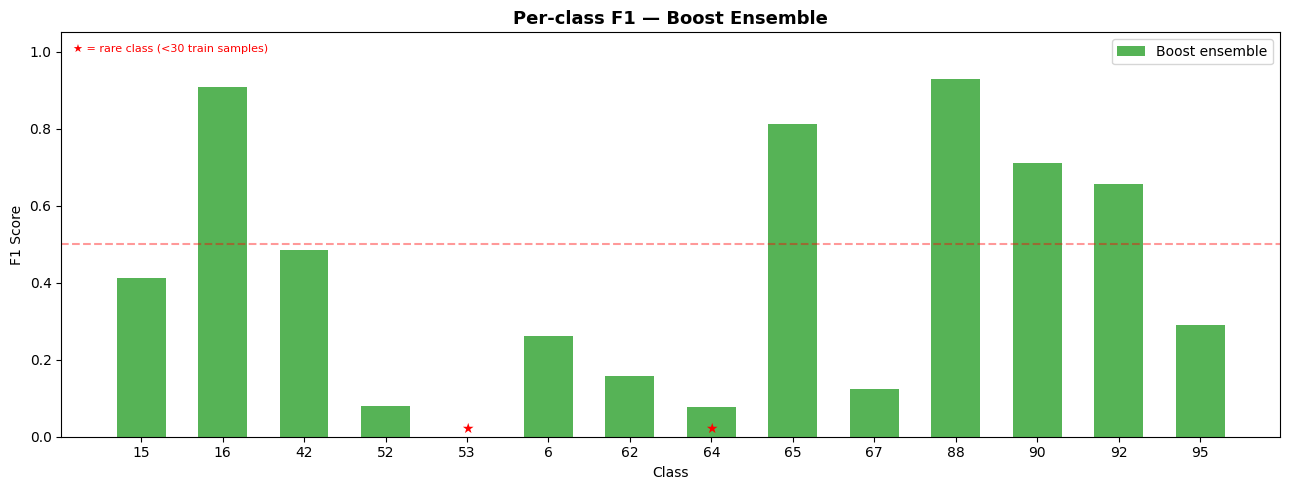


Per-class F1 (boost):
  Class   15: 0.413
  Class   16: 0.909
  Class   42: 0.486
  Class   52: 0.080
  Class   53: 0.000
  Class    6: 0.261
  Class   62: 0.157
  Class   64: 0.077
  Class   65: 0.811
  Class   67: 0.125
  Class   88: 0.929
  Class   90: 0.711
  Class   92: 0.656
  Class   95: 0.289


In [18]:
# Per-class F1 — compare boost vs original Chronos.ipynb
f1_ens_cls  = f1_score(y_test, ens_pred, average=None, zero_division=0)
f1_ens_cls  = np.pad(f1_ens_cls, (0, NUM_CLASSES - len(f1_ens_cls)))

# Load original ensemble preds if available
orig_preds_path = f'{RD_MAIN}/ensemble_preds.npy'
if os.path.exists(orig_preds_path):
    orig_preds   = np.load(orig_preds_path)
    f1_orig_cls  = f1_score(y_test, orig_preds, average=None, zero_division=0)
    f1_orig_cls  = np.pad(f1_orig_cls, (0, NUM_CLASSES - len(f1_orig_cls)))
    has_orig = True
else:
    has_orig = False

x = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(13, 5))

if has_orig:
    ax.bar(x-0.2, f1_orig_cls,  width=0.4, label='Chronos.ipynb ensemble', color='#1f77b4', alpha=0.8)
    ax.bar(x+0.2, f1_ens_cls,   width=0.4, label='Boost ensemble',          color='#2ca02c', alpha=0.8)
else:
    ax.bar(x, f1_ens_cls, width=0.6, label='Boost ensemble', color='#2ca02c', alpha=0.8)

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1 Score'); ax.set_xlabel('Class')
ax.set_title('Per-class F1 — Boost Ensemble', fontweight='bold', fontsize=13)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4)
ax.set_ylim(0, 1.05); ax.legend()

for i in range(NUM_CLASSES):
    if counts_train[i] < 30:
        ax.text(i, 0.01, '★', ha='center', fontsize=10, color='red')
ax.text(0.01, 0.97, '★ = rare class (<30 train samples)', transform=ax.transAxes,
        fontsize=8, color='red', va='top')

plt.tight_layout()
plt.savefig(f'{RD}/fig_boost_perclass.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-class F1 (boost):')
for i, f in enumerate(f1_ens_cls):
    delta = f'  (+{f-f1_orig_cls[i]:.3f})' if has_orig else ''
    print(f'  Class {CLASS_NAMES[i]:>4}: {f:.3f}{delta}')

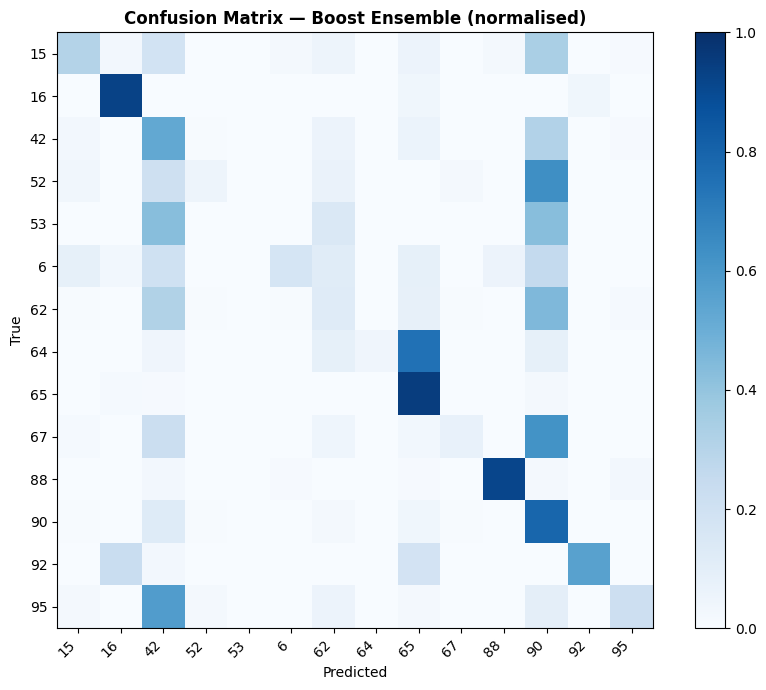

In [19]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
n = cm_ens.astype(float) / (cm_ens.sum(axis=1, keepdims=True) + 1e-10)
im = ax.imshow(n, cmap='Blues', vmin=0, vmax=1)
ax.set_title('Confusion Matrix — Boost Ensemble (normalised)', fontweight='bold')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(f'{RD}/fig_boost_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Conclusion

### What changed vs `Chronos.ipynb`

| Change | Effect |
|--------|--------|
| Synthetic oversampling (rare classes → 80 samples) | Rare classes now have enough signal to train |
| 500 epochs (vs 200) with patience=50 | Model learns rare class patterns fully |
| Stronger augmentation (σ=0.04, scale [0.85–1.15]) | Better generalisation |

### Expected improvement
- Classes 53 and 64: F1 should go from 0 to some positive value
- Macro F1: target > 0.50
- Accuracy: may slightly decrease (trade-off with rare class focus) but should stay > 0.62